In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

from src.scp_core import SCP, uniform_sample_bright_side
from experiments.targets import SkewMultivariateStudentT

In [3]:
d = 100
loc = jnp.linspace(-10, 10, d)
scale_tril = jnp.eye(d) 
df = 2.
alpha = jnp.zeros(d)
alpha = alpha.at[0].set(100)
alpha = alpha.at[1].set(-100)

target = SkewMultivariateStudentT(loc, scale_tril, df, alpha)
exact_samples = target.sample(seed=jax.random.key(0), sample_shape=(1000,))

In [4]:
latitude = 1.1
scp_model = SCP(d, latitude=latitude)

In [5]:
ntrain = 2000
ref_samples = uniform_sample_bright_side(d, latitude, jax.random.key(1), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0. # log scale
}

def loss_fn(params):
    return scp_model.reverse_kl(params, target.log_prob, ref_samples, clip_value=500.)

In [6]:
import optax
import jax_tqdm

def train(loss_fn, params, learning_rate=0.01, max_iter=500):
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    @jax_tqdm.scan_tqdm(max_iter)
    def train_step(carry, _):
        params, opt_state = carry
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), (params, loss)

    init_carry = (params, opt_state)
    carry, params_log = jax.lax.scan(train_step, init_carry, jnp.arange(max_iter))
    params, opt_state = carry
    return params, params_log

In [7]:
opt_params, logs = train(loss_fn, params, learning_rate=0.02, max_iter=4000)

Running for 4,000 iterations: 100%|██████████| 4000/4000 [00:13<00:00, 301.54it/s]


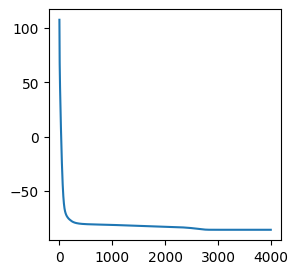

In [8]:
plt.figure(figsize=(3, 3))
plt.plot(logs[1])

In [9]:
def get_cosine(observer, alpha):
    return jnp.dot(observer, alpha) / (jnp.linalg.norm(observer) * jnp.linalg.norm(alpha))

def get_norm(v1, v2):
    return jnp.linalg.norm(v1 - v2) / jnp.linalg.norm(v2)

obs_correlations = jax.vmap(get_cosine, in_axes=(0, None))(logs[0]['observer'], alpha)
loc_correlations = jax.vmap(get_cosine, in_axes=(0, None))(logs[0]['shift'], loc)
loc_norms = jax.vmap(get_norm, in_axes=(0, None))(logs[0]['shift'], loc)

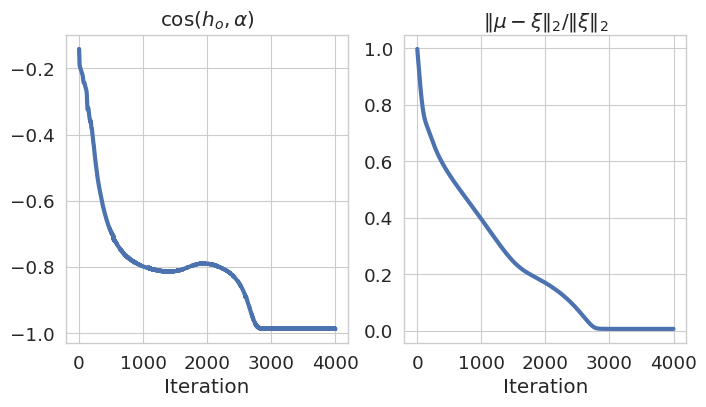

In [11]:
sns.set_theme(context='paper', style='whitegrid', font_scale=1.5)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(obs_correlations, lw=3)
ax[1].plot(loc_norms, lw=3)
ax[0].set_xlabel('Iteration')
ax[1].set_xlabel('Iteration')

ax[0].set_title(r'$\cos(h_o, \alpha)$')
ax[1].set_title(r'$\|\mu - \xi \|_2/\|\xi\|_2$')
plt.savefig(f'experiments/plots/skewt_vi_d{d}_lat{latitude}.pdf', bbox_inches='tight')